# Téléchargement du réseau piéton - Canton de Genève

Ce notebook permet de télécharger et analyser les données de réseau piéton du Canton de Genève depuis OpenStreetMap, en utilisant les classes spécifiques à la marche (pedestrian, footway, steps, etc.).

In [19]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('../../'))

# Imports
import geopandas as gpd
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
import folium
from shapely.geometry import Point, LineString
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("📦 Libraries importées avec succès !")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
📦 Libraries importées avec succès !


In [20]:
output_dir = "../../Data/input/networkGG"
# Mode: 'shapefile' ou 'geocode' — choisir explicitement
area_mode = 'shapefile'  # mettre 'shapefile' pour lire le shp ou 'geocode' pour utiliser le geocode

### 1. Définition de la zone d'étude

In [21]:
%%time
print("🗺️ Définition de la zone d'étude (choix shapefile ou geocode)...")



# Chemin vers le shapefile (si area_mode == 'shapefile')
shp_path = "../../Data/input/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp"

# Si area_mode == 'geocode', liste courte de lieux à géocoder (modifiable)
geocode_places = globals().get('geocode_places', [
    'Divonne-les-Bains, France',
    'Nyon, Switzerland',
    'Versoix, Switzerland'
])

import os

study_area = None

if area_mode == 'shapefile':
    print(f"🔹 Mode shapefile — lecture de: {shp_path}")
    if os.path.exists(shp_path):
        try:
            agglo = gpd.read_file(shp_path)
            if len(agglo) > 1:
                agglo = agglo.dissolve()
            agglo = agglo.to_crs('EPSG:4326')
            study_area = agglo
            print(f"✅ Shapefile chargé: {shp_path} -> {len(study_area)} feature(s)")
        except Exception as e:
            study_area = None
            print(f"❌ Erreur lecture shapefile: {e}\n-> Si vous voulez utiliser le geocodage, changez `area_mode = 'geocode'`")
    else:
        study_area = None
        print(f"⚠️ Shapefile introuvable: {shp_path}. Mettre le bon chemin ou utilisez `area_mode='geocode'`")

elif area_mode == 'geocode':
    print(f"🔹 Mode geocode — géocodage des lieux: {geocode_places}")
    gdfs = []
    for place in geocode_places:
        try:
            g = ox.geocode_to_gdf(place)
            if g is not None and len(g) > 0:
                gdfs.append(g.to_crs('EPSG:4326'))
                print(f"  ✅ {place}")
            else:
                print(f"  ⚠️ Aucun résultat pour: {place}")
        except Exception as e:
            print(f"  ❌ Erreur geocode {place}: {e}")

    if len(gdfs) == 0:
        print("⚠️ Aucun lieu géocodé — vérifier la connexion et les noms. Définir `area_mode='shapefile'` si nécessaire.")
        study_area = None
    else:
        # unionner les géométries pour créer une zone d'étude combinée
        union_geom = gdfs[0].geometry.unary_union
        if len(gdfs) > 1:
            all_geoms = gpd.GeoSeries([g.geometry.unary_union for g in gdfs], crs='EPSG:4326')
            union_geom = all_geoms.unary_union
        study_area = gpd.GeoDataFrame({'name': ['geocode_union']}, geometry=[union_geom], crs='EPSG:4326')
        print(f"✅ Zone d'étude créée par geocodage: {len(study_area)} feature(s)")

else:
    print(f"⚠️ area_mode invalide: {area_mode}. Choisir 'shapefile' ou 'geocode'.")
    study_area = None

# Calcul de la superficie en km² si possible
if study_area is not None:
    try:
        area_km2 = study_area.to_crs('EPSG:2056').geometry.area.iloc[0] / 1e6
        print(f"📐 Superficie (approx.): {area_km2:.2f} km²")
    except Exception:
        print("⚠️ Impossible de calculer la superficie (géométrie ou CRS inconnus)")

study_area


🗺️ Définition de la zone d'étude (choix shapefile ou geocode)...
🔹 Mode shapefile — lecture de: ../../Data/input/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp
✅ Shapefile chargé: ../../Data/input/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp -> 1 feature(s)
📐 Superficie (approx.): 2212.74 km²
CPU times: user 11.8 ms, sys: 4.62 ms, total: 16.4 ms
Wall time: 17.8 ms


,OBJECTID,DESCRIPTIO,SHAPE_AREA,SHAPE_LEN,geometry
0,1,Périmètre fonctionnel de l'agglomération du Gr...,2.212742e+09,370537.985684,"POLYGON ((6.15995 46.54286, 6.16101 46.54184, ..."


<Axes: >

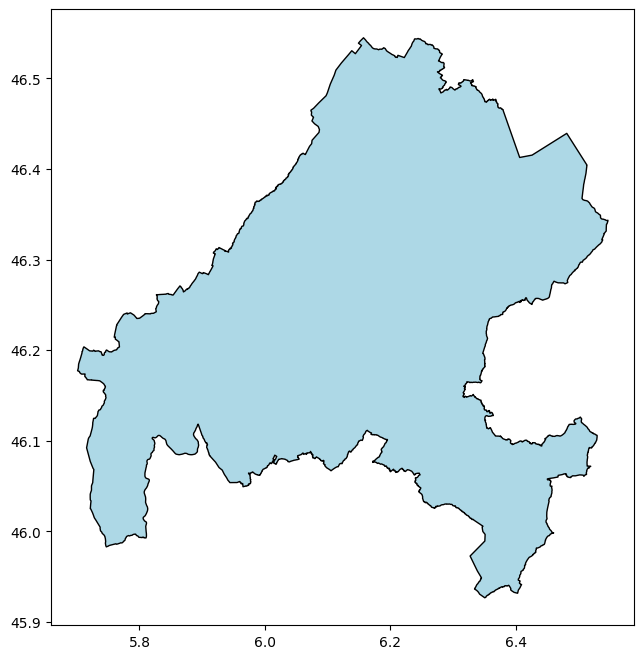

In [22]:
study_area.plot(figsize=(8, 8), color='lightblue', edgecolor='black')

In [23]:
# # Import manquant pour la bounding box
# from shapely.geometry import box

# # Visualisation rapide de la zone
# m_canton = folium.Map(location=[46.25, 6.15], zoom_start=10, tiles='CartoDB Positron')

# # Ajouter les limites du canton
# folium.GeoJson(
#     canton_geneve.__geo_interface__,
#     style_function=lambda x: {
#         'fillColor': '#3489db',
#         'color': '#E60000',
#         'weight': 2,
#         'fillOpacity': 0.1,
#     }
# ).add_to(m_canton)

# print("🗺️ Carte des limites créée (exécuter m_canton pour l'afficher)")
# m_canton  # Décommenter pour afficher

### 2. Helpers

In [24]:
import geopandas as gpd
import osmnx as ox


def get_platforms_from_polygon(poly, tags):
    """
    Version-agnostic OSMnx getter:
    - essaie ox.features_from_polygon (OSMnx ≥ 1.1)
    - sinon ox.geometries_from_polygon (OSMnx ~1.0)
    - sinon fallback bbox: ox.geometries_from_bbox + clip au polygone

    Retourne un GeoDataFrame (potentiellement vide) avec CRS EPSG:4326.
    """
    # 1) versions récentes
    try:
        res = ox.features_from_polygon(poly, tags=tags)
        return gpd.GeoDataFrame(res, geometry='geometry', crs='EPSG:4326') if res is not None else gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
    except Exception:
        pass

    # 2) versions un peu plus anciennes
    try:
        res = ox.geometries_from_polygon(poly, tags=tags)
        return gpd.GeoDataFrame(res, geometry='geometry', crs='EPSG:4326') if res is not None else gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
    except Exception:
        pass

    # 3) fallback très compatible: BBOX + clip
    try:
        minx, miny, maxx, maxy = poly.bounds
        north, south, east, west = maxy, miny, maxx, minx
        gdf_bbox = ox.geometries_from_bbox(north, south, east, west, tags=tags)
        try:
            clipped = gpd.clip(gdf_bbox, poly)
            return gpd.GeoDataFrame(clipped, geometry='geometry', crs='EPSG:4326')
        except Exception:
            clipped = gdf_bbox[gdf_bbox.geometry.intersects(poly)]
            return gpd.GeoDataFrame(clipped, geometry='geometry', crs='EPSG:4326')
    except Exception:
        # retourne gdf vide si tout échoue
        return gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')


# Tags élargis pour récupérer les plateformes/aires d'arrêt (surfaces) et variantes
platform_tags = {
    'public_transport': ['platform', 'stop_position', 'stop_area'],
    'railway': ['platform', 'tram_stop'],
    'amenity': ['bus_station', 'bus_stop'],
    'highway': ['bus_stop', 'platform'],
    # parfois décrit avec 'public_transport:version' ou 'public_transport:platform'
    # on récupérera aussi les aires dont le tag est présent via features_from_polygon
}

print('Helper get_platforms_from_polygon chargé — tags plateformes étendus')


Helper get_platforms_from_polygon chargé — tags plateformes étendus


### 3. Téléchargement du réseau piéton

Nous allons télécharger spécifiquement les infrastructures dédiées à la marche selon les classifications OpenStreetMap.

In [25]:
# Définition des filtres OSM pour les infrastructures piétonnes
pedestrian_filters = {
    # Chemins spécifiquement piétons
    'footway': True,                    # Trottoirs et chemins piétons
    'pedestrian': True,                 # Zones piétonnes
    'steps': True,                      # Escaliers
    'path': ['foot', 'designated'],     # Sentiers autorisés aux piétons
    
    # Routes avec accès piéton
    'highway': [
        'footway',
        'pedestrian', 
        'steps',
        'path',
        'living_street',                # Zones de rencontre
        'residential',                  # Rues résidentielles (avec trottoirs)
        'tertiary',                     # Routes tertiaires (souvent avec trottoirs)
        'unclassified',                 # Routes non classées
        'service',                      # Voies de service
        'platform'
    ],
    
    # Ajout pour public_transport
    'public_transport': [
        'platform'           
    ],
    
    # Attributs spéciaux pour les piétons
    'foot': ['yes', 'designated', 'permissive'],
    'sidewalk': ['both', 'left', 'right', 'yes'],  # Présence de trottoirs
    
    # Attributs spécifiques aux passages piétons
    'crossing': ['traffic_signals', 'uncontrolled', 'zebra', 'unmarked'],
    'crossing:signals': ['yes'],
    'tactile_paving': ['yes'],          # Bandes podotactiles
}

print("🚶 Filtres OSM définis pour les infrastructures piétonnes")
print(f"📝 Types d'infrastructures incluses:")
for key, values in pedestrian_filters.items():
    if isinstance(values, list):
        print(f"   • {key}: {', '.join(values)}")
    else:
        print(f"   • {key}: {values}")

🚶 Filtres OSM définis pour les infrastructures piétonnes
📝 Types d'infrastructures incluses:
   • footway: True
   • pedestrian: True
   • steps: True
   • path: foot, designated
   • highway: footway, pedestrian, steps, path, living_street, residential, tertiary, unclassified, service, platform
   • public_transport: platform
   • foot: yes, designated, permissive
   • sidewalk: both, left, right, yes
   • crossing: traffic_signals, uncontrolled, zebra, unmarked
   • crossing:signals: yes
   • tactile_paving: yes


In [26]:
%%time
# Téléchargement des réseaux piéton et cyclable pour le Grand Genève
print("🔄 Téléchargement des réseaux piéton et cyclable en cours...")
print("⚠️ Cette opération peut prendre plusieurs minutes...")

poly = study_area.geometry.iloc[0]

# 1) Réseau piéton (walk)
print('\n🚶 Téléchargement réseau piéton (OSMnx network_type="walk")...')
pedestrian_network = ox.graph_from_polygon(
    polygon=poly,
    network_type='walk',
    simplify=True,
    retain_all=True
)
print(f"✅ Réseau piéton téléchargé: {len(pedestrian_network.nodes)} nœuds, {len(pedestrian_network.edges)} arêtes")

# 2) Réseau cyclable (bike)
print('\n🚲 Téléchargement réseau cyclable (OSMnx network_type="bike")...')
bicycle_network = ox.graph_from_polygon(
    polygon=poly,
    network_type='bike',
    simplify=True,
    retain_all=True
)
print(f"✅ Réseau cyclable téléchargé: {len(bicycle_network.nodes)} nœuds, {len(bicycle_network.edges)} arêtes")

# Remarque: selon la qualité d'OSM, certains types peuvent être mieux récupérés avec custom_filter ou 'all' puis filtrage.


🔄 Téléchargement des réseaux piéton et cyclable en cours...
⚠️ Cette opération peut prendre plusieurs minutes...

🚶 Téléchargement réseau piéton (OSMnx network_type="walk")...
✅ Réseau piéton téléchargé: 164572 nœuds, 420054 arêtes

🚲 Téléchargement réseau cyclable (OSMnx network_type="bike")...
✅ Réseau cyclable téléchargé: 113218 nœuds, 254626 arêtes
CPU times: user 1min 39s, sys: 2.72 s, total: 1min 42s
Wall time: 1min 42s


In [27]:
# Conversion en GeoDataFrames pour analyse et export
print("🔄 Conversion en GeoDataFrames...")

# Piéton
nodes_gdf = ox.graph_to_gdfs(pedestrian_network, edges=False)
edges_gdf = ox.graph_to_gdfs(pedestrian_network, nodes=False)

# Cyclable
bike_nodes_gdf = ox.graph_to_gdfs(bicycle_network, edges=False)
bike_edges_gdf = ox.graph_to_gdfs(bicycle_network, nodes=False)

print(f"📊 Piéton - Nœuds: {len(nodes_gdf)} points")
print(f"📊 Piéton - Arêtes: {len(edges_gdf)} segments")
print(f"📊 Cyclable - Nœuds: {len(bike_nodes_gdf)} points")
print(f"📊 Cyclable - Arêtes: {len(bike_edges_gdf)} segments")

# Afficher les colonnes disponibles pour les arêtes piéton
print(f"\n📋 Colonnes des arêtes piéton: {list(edges_gdf.columns)}")

# Vérifier la présence de trottoirs
if 'sidewalk' in edges_gdf.columns:
    sidewalk_counts = edges_gdf['sidewalk'].value_counts()
    print(f"\n🚶 Présence de trottoirs (piéton):")
    for sidewalk_type, count in sidewalk_counts.items():
        print(f"   • {sidewalk_type}: {count}")

# Vérifier la présence d'aménagements cyclables dans les arêtes cyclables
bike_tags = ['cycling', 'bicycle', 'cycleway']
for tag in bike_tags:
    if tag in bike_edges_gdf.columns:
        print(f"\n🚲 '{tag}' presente dans bike arêtes: {bike_edges_gdf[tag].notna().sum()}")


🔄 Conversion en GeoDataFrames...
📊 Piéton - Nœuds: 164572 points
📊 Piéton - Arêtes: 420054 segments
📊 Cyclable - Nœuds: 113218 points
📊 Cyclable - Arêtes: 254626 segments

📋 Colonnes des arêtes piéton: ['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'ref', 'oneway', 'reversed', 'length', 'geometry', 'tunnel', 'access', 'bridge', 'service', 'junction', 'width', 'area']


In [28]:
# Filtrer spécifiquement les infrastructures dédiées aux piétons
print("🎯 Filtrage des infrastructures spécifiquement piétonnes...")

# Types d'infrastructures prioritaires pour les piétons
pedestrian_priority = ['footway', 'pedestrian', 'steps', 'path', 'bus_stop', 'track']
pedestrian_secondary = ['living_street', 'residential', 'service']

# Créer des sous-ensembles avec .copy() pour éviter SettingWithCopyWarning
priority_pedestrian = edges_gdf[edges_gdf['highway'].isin(pedestrian_priority)].copy()
secondary_pedestrian = edges_gdf[edges_gdf['highway'].isin(pedestrian_secondary)].copy()

# Segments avec trottoirs explicites
if 'sidewalk' in edges_gdf.columns:
    sidewalk_segments = edges_gdf[edges_gdf['sidewalk'].notna() & 
                                  edges_gdf['sidewalk'].isin(['both', 'left', 'right', 'yes'])].copy()
else:
    sidewalk_segments = gpd.GeoDataFrame()

print(f"🚶 Infrastructures prioritaires piétons: {len(priority_pedestrian)}")
print(f"🏘️ Infrastructures secondaires (résidentielles): {len(secondary_pedestrian)}")
print(f"🛤️ Segments avec trottoirs explicites: {len(sidewalk_segments)}")


🎯 Filtrage des infrastructures spécifiquement piétonnes...
🚶 Infrastructures prioritaires piétons: 170276
🏘️ Infrastructures secondaires (résidentielles): 155400
🛤️ Segments avec trottoirs explicites: 0


In [29]:
# Ajouter cette cellule après le filtrage des arêtes
print("🔗 Isolation des nœuds spécifiques aux réseaux prioritaires et secondaires...")

# Récupérer les nœuds uniques des arêtes prioritaires
if len(priority_pedestrian) > 0:
    # Les arêtes ont des index multi-niveaux (u, v, key) où u et v sont les nœuds
    priority_node_ids = set()
    for edge_index in priority_pedestrian.index:
        priority_node_ids.add(edge_index[0])  # nœud de départ (u)
        priority_node_ids.add(edge_index[1])  # nœud d'arrivée (v)
    
    # Filtrer les nœuds correspondants
    priority_nodes = nodes_gdf[nodes_gdf.index.isin(priority_node_ids)].copy()
else:
    priority_nodes = gpd.GeoDataFrame()

# Récupérer les nœuds uniques des arêtes secondaires
if len(secondary_pedestrian) > 0:
    secondary_node_ids = set()
    for edge_index in secondary_pedestrian.index:
        secondary_node_ids.add(edge_index[0])  # nœud de départ (u)
        secondary_node_ids.add(edge_index[1])  # nœud d'arrivée (v)
    
    # Filtrer les nœuds correspondants
    secondary_nodes = nodes_gdf[nodes_gdf.index.isin(secondary_node_ids)].copy()
else:
    secondary_nodes = gpd.GeoDataFrame()

# Nœuds avec trottoirs explicites
if len(sidewalk_segments) > 0:
    sidewalk_node_ids = set()
    for edge_index in sidewalk_segments.index:
        sidewalk_node_ids.add(edge_index[0])
        sidewalk_node_ids.add(edge_index[1])
    
    sidewalk_nodes = nodes_gdf[nodes_gdf.index.isin(sidewalk_node_ids)].copy()
else:
    sidewalk_nodes = gpd.GeoDataFrame()

print(f"🚶 Nœuds du réseau prioritaire: {len(priority_nodes)}")
print(f"🏘️ Nœuds du réseau secondaire: {len(secondary_nodes)}")
print(f"🛤️ Nœuds avec trottoirs: {len(sidewalk_nodes)}")

# Analyser les intersections entre réseaux
if len(priority_nodes) > 0 and len(secondary_nodes) > 0:
    shared_nodes = set(priority_nodes.index).intersection(set(secondary_nodes.index))
    print(f"🔗 Nœuds partagés entre prioritaire/secondaire: {len(shared_nodes)}")

# Analyser le degré de connectivité des nœuds prioritaires
if len(priority_nodes) > 0:
    # Calculer le degré de chaque nœud (nombre de connexions)
    node_degrees = {}
    for edge_index in priority_pedestrian.index:
        u, v = edge_index[0], edge_index[1]
        node_degrees[u] = node_degrees.get(u, 0) + 1
        node_degrees[v] = node_degrees.get(v, 0) + 1
    
    # Ajouter les degrés aux nœuds prioritaires
    priority_nodes.loc[:, 'degree'] = [node_degrees.get(node_id, 0) for node_id in priority_nodes.index]
    
    print(f"\n📊 Statistiques de connectivité des nœuds prioritaires:")
    print(f"   • Degré moyen: {priority_nodes['degree'].mean():.1f}")
    print(f"   • Degré maximum: {priority_nodes['degree'].max()}")
    print(f"   • Nœuds de forte connectivité (≥4 connexions): {len(priority_nodes[priority_nodes['degree'] >= 4])}")

🔗 Isolation des nœuds spécifiques aux réseaux prioritaires et secondaires...
🚶 Nœuds du réseau prioritaire: 83818
🏘️ Nœuds du réseau secondaire: 84755
🛤️ Nœuds avec trottoirs: 0
🔗 Nœuds partagés entre prioritaire/secondaire: 16490

📊 Statistiques de connectivité des nœuds prioritaires:
   • Degré moyen: 4.1
   • Degré maximum: 14
   • Nœuds de forte connectivité (≥4 connexions): 49595


## 3. Visualisation du réseau piéton

In [30]:
# # Créer une carte interactive du réseau piéton
# print("🗺️ Création de la carte interactive...")

# # Carte centrée sur Genève
# center_lat, center_lon = 46.2043907, 6.1431577
# m_pedestrian = folium.Map(
#     location=[center_lat, center_lon], 
#     zoom_start=11, 
#     tiles='CartoDB Positron'  # Utiliser un fond clair
# )

# # Fonction pour définir les couleurs selon le type d'infrastructure
# def get_color(highway_type):
#     color_map = {
#         'footway': '#E60000',        # Rouge - trottoirs
#         'pedestrian': '#F8D27D',     # Jaune - zones piétonnes  
#         'steps': '#3489db',          # Bleu - escaliers
#         'path': '#96C8A6',           # Vert - sentiers
#         'living_street': '#DFAB9A',  # Rose - zones de rencontre
#         'residential': '#cccccc'     # Gris - résidentiel
#     }
#     return color_map.get(highway_type, '#666666')

# # Ajouter les infrastructures prioritaires
# if len(priority_pedestrian) > 0:
#     for _, row in priority_pedestrian.head(1000).iterrows():  # Limiter pour performance
#         folium.PolyLine(
#             locations=[[coord[1], coord[0]] for coord in row.geometry.coords],
#             color=get_color(row['highway']),
#             weight=2,
#             opacity=0.8,
#             popup=f"Type: {row['highway']}"
#         ).add_to(m_pedestrian)

# # Ajouter les nœuds prioritaires sur la carte
# if len(priority_nodes) > 0:
#     for _, node in priority_nodes.head(500).iterrows():  # Limiter pour performance
#         folium.CircleMarker(
#             location=[node.geometry.y, node.geometry.x],
#             radius=0.3 if node.get('degree', 0) < 4 else 1,  # Taille selon connectivité
#             color='#E60000',
#             fillColor='#E60000',
#             fillOpacity=0.7,
#             popup=f"Nœud prioritaire<br>Connexions: {node.get('degree', 'N/A')}"
#         ).add_to(m_pedestrian)

# # Légende
# legend_html = '''
# <div style="position: fixed; 
#             bottom: 50px; left: 50px; width: 200px; height: 120px; 
#             background-color: white; border:2px solid grey; z-index:9999; 
#             font-size:14px; padding: 10px">
# <p><b>Réseau piéton</b></p>
# <p><i class="fa fa-minus" style="color:#E60000"></i> Trottoirs (footway)</p>
# <p><i class="fa fa-minus" style="color:#F8D27D"></i> Zones piétonnes</p>
# <p><i class="fa fa-minus" style="color:#3489db"></i> Escaliers</p>
# <p><i class="fa fa-minus" style="color:#96C8A6"></i> Sentiers</p>
# </div>
# '''
# m_pedestrian.get_root().html.add_child(folium.Element(legend_html))

# print("✅ Carte créée (exécuter m_pedestrian pour l'afficher)")
# m_pedestrian  # Décommenter pour afficher

## 4. Export et sauvegarde des données

In [31]:
# Nettoyage et inspection avant export Parquet + plateformes
import pandas as pd
import geopandas as gpd

print('➡️ Normalisation des colonnes list-like (ex: osmid) pour compatibility parquet')

def normalize_listlike_columns_inplace(gdf):
    changed = []
    for col in gdf.columns:
        try:
            has_list = gdf[col].apply(lambda x: isinstance(x, list)).any()
            has_nonlist = gdf[col].apply(lambda x: (not isinstance(x, list)) and pd.notnull(x)).any()
        except Exception:
            continue
        if has_list and has_nonlist:
            gdf[col] = gdf[col].apply(lambda x: x if isinstance(x, list) else ([x] if pd.notnull(x) else []))
            changed.append(col)
    return changed

if 'edges_gdf' in globals():
    changed = normalize_listlike_columns_inplace(edges_gdf)
    # ensure osmid is list everywhere
    if 'osmid' in edges_gdf.columns:
        edges_gdf['osmid'] = edges_gdf['osmid'].apply(lambda x: x if isinstance(x, list) else ([x] if pd.notnull(x) else []))
        if 'osmid' not in changed:
            changed.append('osmid')
    print('Edges normalized columns:', changed)
else:
    print("⚠️ 'edges_gdf' non défini — exécute la cellule de conversion du réseau d'abord")

if 'bike_edges_gdf' in globals():
    changed_b = normalize_listlike_columns_inplace(bike_edges_gdf)
    if 'osmid' in bike_edges_gdf.columns:
        bike_edges_gdf['osmid'] = bike_edges_gdf['osmid'].apply(lambda x: x if isinstance(x, list) else ([x] if pd.notnull(x) else []))
        if 'osmid' not in changed_b:
            changed_b.append('osmid')
    print('Bike edges normalized columns:', changed_b)
else:
    print("⚠️ 'bike_edges_gdf' non défini — exécute la cellule de conversion du réseau d'abord")

# Inspection et conversion des plateformes récupérées
print('\n➡️ Inspection des plateformes brutes (plats_raw)')
if 'plats_raw' in globals():
    try:
        print('Types de géométrie:', plats_raw.geometry.type.value_counts().to_dict())
        sample_cols = [c for c in ['public_transport', 'amenity', 'railway', 'highway', 'name'] if c in plats_raw.columns]
        if len(sample_cols) > 0:
            print('\nAperçu des attributs (quelques lignes):')
            display(plats_raw[sample_cols].head())
    except Exception as e:
        print('Erreur inspection plats_raw:', e)

    # Construire plats_polygons: garder les polygons et tamponner les points en petites surfaces
    polys = plats_raw[plats_raw.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    pts = plats_raw[plats_raw.geometry.type == 'Point'].copy()
    plats_polygons = polys
    if len(pts) > 0:
        # tamponner en mètres (3 m par défaut) en projection métrique
        buf_m = globals().get('platform_point_buffer_m', 3)
        pts_m = pts.to_crs(epsg=3857)
        pts_m['geometry'] = pts_m.geometry.buffer(buf_m)
        pts_buf = pts_m.to_crs(epsg=4326)
        plats_polygons = pd.concat([polys, pts_buf], ignore_index=True)
        print(f'Converti {len(pts)} points en surfaces tamponnées ({buf_m} m) — total surfaces: {len(plats_polygons)}')
    else:
        print('Aucun point plateforme à tamponner — surfaces trouvées:', len(polys))

    # calcul area/perimeter si des surfaces
    if len(plats_polygons) > 0:
        pm = gpd.GeoDataFrame(plats_polygons, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)
        plats_polygons = gpd.GeoDataFrame(plats_polygons, geometry='geometry', crs='EPSG:4326')
        plats_polygons['area_m2'] = pm.geometry.area
        plats_polygons['perimeter_m'] = pm.geometry.length
    # remettre dans l'espace de noms global pour que les cellules suivantes l'utilisent
    globals()['plats_polygons'] = plats_polygons
    print('\n✅ plats_polygons préparé — exécute ensuite la cellule d\'export rapide')
else:
    print('⚠️ plats_raw introuvable — exécute d\'abord la cellule qui récupère les plateformes')

print('\nConseil: exécute cette cellule, puis ré-exécute la cellule d\'export rapide pour générer le parquet.')


➡️ Normalisation des colonnes list-like (ex: osmid) pour compatibility parquet
Edges normalized columns: ['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'ref', 'reversed', 'tunnel', 'access', 'bridge', 'service', 'width']
Bike edges normalized columns: ['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'ref', 'reversed', 'access', 'service', 'tunnel', 'width', 'bridge']

➡️ Inspection des plateformes brutes (plats_raw)
Types de géométrie: {'Point': 5536, 'LineString': 1653, 'Polygon': 332}

Aperçu des attributs (quelques lignes):


public_transport amenity railway   highway  \
element id                                                    
node    497307      stop_position     NaN     NaN  bus_stop   
        497950      stop_position     NaN     NaN       NaN   
        2810322     stop_position     NaN     NaN       NaN   
        25599026    stop_position     NaN     NaN       NaN   
        25653510    stop_position     NaN     NaN       NaN   

                                name  
element id                            
node    497307               Nations  
        497950                 Plage  
        2810322             Florence  
        25599026  Thoiry - Allemogne  
        25653510      Contrat-Social

Converti 5536 points en surfaces tamponnées (3 m) — total surfaces: 5868

✅ plats_polygons préparé — exécute ensuite la cellule d'export rapide

Conseil: exécute cette cellule, puis ré-exécute la cellule d'export rapide pour générer le parquet.


In [ ]:
# --- Simplified export cell
import geopandas as gpd
import os

# Choix des formats à exporter — modifier avant d'exécuter
export_formats_choice = globals().get('export_formats_choice', ['geoparquet'])
# options possibles: 'geoparquet', 'shapefile', 'geojson', 'pickle'

os.makedirs(output_dir, exist_ok=True)

def export_data(gdf, filename_base, formats=None):
    """Exporter un GeoDataFrame dans les formats choisis.
    - parquet/pickle conservent les types natifs (listes/dicts)
    - shapefile/geojson convertissent les colonnes list-like en string
    """
    if formats is None:
        formats = export_formats_choice

    available = {'geoparquet', 'shapefile', 'geojson', 'pickle'}
    to_do = [f for f in formats if f in available]
    if len(to_do) == 0:
        print("⚠️ Aucun format valide sélectionné dans export_formats_choice")
        return []

    exported = []
    for fmt in to_do:
        try:
            if fmt == 'geoparquet':
                path = os.path.join(output_dir, f"{filename_base}.parquet")
                gdf.to_parquet(path)
            elif fmt == 'pickle':
                path = os.path.join(output_dir, f"{filename_base}.pkl")
                gdf.to_pickle(path)
            else:
                # shapefile / geojson: coerce list-like cols
                gdf_write = gdf.copy()
                for col in gdf_write.columns:
                    try:
                        if gdf_write[col].apply(lambda x: isinstance(x, (list, tuple))).any():
                            gdf_write[col] = gdf_write[col].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, (list, tuple)) else x)
                    except Exception:
                        pass
                if fmt == 'shapefile':
                    shp_dir = os.path.join(output_dir, f"shp_{filename_base}")
                    os.makedirs(shp_dir, exist_ok=True)
                    path = os.path.join(shp_dir, f"{filename_base}.shp")
                    gdf_write.to_file(path)
                else:  # geojson
                    path = os.path.join(output_dir, f"{filename_base}.geojson")
                    gdf_write.to_file(path, driver='GeoJSON')

            exported.append(path)
            print(f"✅ {fmt}: {path}")
        except Exception as e:
            print(f"❌ Échec export {fmt} pour {filename_base}: {e}")

    return exported


# --- Platform extraction over the full study_area
if 'study_area' not in globals() or study_area is None:
    raise ValueError("study_area not defined. Run the study area cell first (set `area_mode` and create `study_area`).")
poly = study_area.geometry.unary_union if hasattr(study_area.geometry, 'unary_union') else study_area.geometry.iloc[0]
dev_poly = poly
print(f"Using full study_area for extraction (features: {len(study_area)}).")

# Extract platforms using helper
print("🔎 Extraction des plateformes (polygons) dans la study_area...")
plats_raw = get_platforms_from_polygon(dev_poly, tags=platform_tags)
if plats_raw is None or len(plats_raw) == 0:
    print("⚠️ Aucun objet plateforme récupéré")
    plats_polygons = gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
else:
    plats = gpd.GeoDataFrame(plats_raw.reset_index(drop=True), geometry='geometry', crs='EPSG:4326')
    plats_polygons = plats[plats.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    if len(plats_polygons) > 0:
        p_m = plats_polygons.to_crs(epsg=3857)
        plats_polygons['area_m2'] = p_m.geometry.area
        plats_polygons['perimeter_m'] = p_m.geometry.length
    print(f"Trouvé {len(plats)} géométries; {len(plats_polygons)} surfaces")

# Link to nearest edges/nodes if possible
# if len(plats_polygons) > 0 and 'edges_gdf' in globals():
#     plats_centroid = plats_polygons.copy()
#     plats_centroid['centroid'] = plats_centroid.geometry.centroid
#     plats_centroid = plats_centroid.set_geometry('centroid').to_crs(epsg=3857)

#     # Prepare edges/nodes with a stable integer index column for joins
#     edges_m = edges_gdf.to_crs(epsg=3857).reset_index()
#     if 'edge_index' not in edges_m.columns:
#         edges_m = edges_m.reset_index().rename(columns={'index': 'edge_index'})

#     bike_edges_m = bike_edges_gdf.to_crs(epsg=3857).reset_index()
#     if 'bike_edge_index' not in bike_edges_m.columns:
#         bike_edges_m = bike_edges_m.reset_index().rename(columns={'index': 'bike_edge_index'})

#     nodes_m = nodes_gdf.to_crs(epsg=3857).reset_index()
#     if 'node_id' not in nodes_m.columns:
#         nodes_m = nodes_m.reset_index().rename(columns={'index': 'node_id'})

#     bike_nodes_m = bike_nodes_gdf.to_crs(epsg=3857).reset_index()
#     if 'bike_node_id' not in bike_nodes_m.columns:
#         bike_nodes_m = bike_nodes_m.reset_index().rename(columns={'index': 'bike_node_id'})

#     ped_match = gpd.sjoin_nearest(plats_centroid[['geometry']], edges_m[['edge_index','geometry']], how='left', max_distance=100, distance_col='dist_to_ped_edge')
#     plats_polygons['nearest_ped_edge_index'] = ped_match['edge_index'].values
#     plats_polygons['dist_to_ped_edge_m'] = ped_match['dist_to_ped_edge'].values

#     bike_match = gpd.sjoin_nearest(plats_centroid[['geometry']], bike_edges_m[['bike_edge_index','geometry']], how='left', max_distance=100, distance_col='dist_to_bike_edge')
#     plats_polygons['nearest_bike_edge_index'] = bike_match['bike_edge_index'].values
#     plats_polygons['dist_to_bike_edge_m'] = bike_match['dist_to_bike_edge'].values

#     node_match = gpd.sjoin_nearest(plats_centroid[['geometry']], nodes_m[['node_id','geometry']], how='left', max_distance=100, distance_col='dist_to_ped_node')
#     plats_polygons['nearest_ped_node_id'] = node_match['node_id'].values
#     plats_polygons['dist_to_ped_node_m'] = node_match['dist_to_ped_node'].values

#     bike_node_match = gpd.sjoin_nearest(plats_centroid[['geometry']], bike_nodes_m[['bike_node_id','geometry']], how='left', max_distance=100, distance_col='dist_to_bike_node')
#     plats_polygons['nearest_bike_node_id'] = bike_node_match['bike_node_id'].values
#     plats_polygons['dist_to_bike_node_m'] = bike_node_match['dist_to_bike_node'].values

#     print("🔗 Plateformes rattachées aux arêtes/nœuds (max 100 m)")
# else:
#     print("ℹ️ Pas de plateformes/pas de edges_gdf disponibles pour rattachement")

# Export selon la sélection
if len(plats_polygons) > 0:
    export_data(plats_polygons, 'grandgeneve_platforms')
else:
    print('Aucune platform à exporter')

# Export principaux jeux (utilise export_formats_choice)
for name, gdf, fname in [
    ('ped nodes', globals().get('nodes_gdf', None), 'grandgeneve_pedestrian_nodes'),
    ('ped edges', globals().get('edges_gdf', None), 'grandgeneve_pedestrian_edges_all'),
    ('bike nodes', globals().get('bike_nodes_gdf', None), 'grandgeneve_bicycle_nodes'),
    ('bike edges', globals().get('bike_edges_gdf', None), 'grandgeneve_bicycle_edges_all'),
]:
    if gdf is not None:
        print(f"\n💾 Export {name} -> {fname} (formats: {export_formats_choice})")
        export_data(gdf, fname)

print('\n✅ Exports terminés. Vérifie le dossier:', output_dir)


/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_18802/1042765768.py:63: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = study_area.geometry.unary_union if hasattr(study_area.geometry, 'unary_union') else study_area.geometry.iloc[0]


Using full study_area for extraction (features: 1).
🔎 Extraction des plateformes (polygons) dans la study_area...
Trouvé 7521 géométries; 332 surfaces
✅ geoparquet: ../../Data/input/networkGG/grandgeneve_platforms.parquet

💾 Export ped nodes -> grandgeneve_pedestrian_nodes (formats: ['geoparquet'])
✅ geoparquet: ../../Data/input/networkGG/grandgeneve_pedestrian_nodes.parquet

💾 Export ped edges -> grandgeneve_pedestrian_edges_all (formats: ['geoparquet'])
✅ geoparquet: ../../Data/input/networkGG/grandgeneve_pedestrian_edges_all.parquet

💾 Export bike nodes -> grandgeneve_bicycle_nodes (formats: ['geoparquet'])
✅ geoparquet: ../../Data/input/networkGG/grandgeneve_bicycle_nodes.parquet

💾 Export bike edges -> grandgeneve_bicycle_edges_all (formats: ['geoparquet'])
✅ geoparquet: ../../Data/input/networkGG/grandgeneve_bicycle_edges_all.parquet

✅ Exports terminés. Vérifie le dossier: ../../Data/input/networkGG


In [40]:
# Create a summary file with stats about the networks and a documentation
import os, json, textwrap
from datetime import datetime
import pandas as pd
import geopandas as gpd

os.makedirs(output_dir, exist_ok=True)
summary = {}

# Study area info (if available)
sa = globals().get('study_area')
if sa is None:
    summary['study_area_features'] = None
    summary['area_km2'] = None
else:
    try:
        summary['study_area_features'] = int(len(sa))
    except Exception:
        summary['study_area_features'] = None
    try:
        summary['area_km2'] = float(sa.to_crs('EPSG:2056').geometry.area.iloc[0] / 1e6)
    except Exception:
        summary['area_km2'] = None

# Helper to describe a GeoDataFrame (safe)
def describe_gdf(gdf):
    if gdf is None:
        return {'count': None, 'crs': None, 'columns': []}
    try:
        cols = list(gdf.columns)
    except Exception:
        cols = []
    out = {'count': int(len(gdf)), 'crs': str(getattr(gdf, 'crs', None)), 'columns': cols}
    # detect list-like columns
    listcols = []
    for c in cols:
        try:
            if gdf[c].apply(lambda x: isinstance(x, (list, tuple))).any():
                listcols.append(c)
        except Exception:
            pass
    out['list_like_columns'] = listcols
    return out

# Networks overview
summary['pedestrian_nodes'] = describe_gdf(globals().get('nodes_gdf'))
summary['pedestrian_edges'] = describe_gdf(globals().get('edges_gdf'))
summary['bicycle_nodes'] = describe_gdf(globals().get('bike_nodes_gdf'))
summary['bicycle_edges'] = describe_gdf(globals().get('bike_edges_gdf'))

# Sample attribute distributions for bicycle edges to help preserve important tags
bike_samples = {}
b_g = globals().get('bike_edges_gdf')
if b_g is not None and len(b_g) > 0:
    for tag in ['cycleway','bicycle','highway','surface','lanes','oneway','cycleway:left','cycleway:right']:
        if tag in b_g.columns:
            try:
                bike_samples[tag] = b_g[tag].value_counts().head(10).to_dict()
            except Exception:
                bike_samples[tag] = None
summary['bike_edge_samples'] = bike_samples

# Platforms summary (if present)
plats = None
for _name in ['plats_polygons', 'plats', 'plats_raw']:
    _val = globals().get(_name)
    if _val is not None:
        plats = _val
        break

if plats is None:
    summary['platforms_count'] = None
    summary['platforms_surfaces'] = None
else:
    try:
        summary['platforms_count'] = int(len(plats))
    except Exception:
        summary['platforms_count'] = None
    try:
        if hasattr(plats, 'geometry') and 'geometry' in plats.columns:
            summary['platforms_surfaces'] = int(len(plats[plats.geometry.type.isin(['Polygon','MultiPolygon'])]))
        else:
            summary['platforms_surfaces'] = 0
    except Exception:
        summary['platforms_surfaces'] = None

# Extracted columns overview
extracted = {}
for label, g in [('ped_edges', globals().get('edges_gdf')), ('bike_edges', globals().get('bike_edges_gdf')), ('plats', plats)]:
    if g is not None:
        try:
            extracted[label] = list(g.columns)
        except Exception:
            extracted[label] = []
summary['extracted_columns'] = extracted

# write JSON summary
json_path = os.path.join(output_dir, 'extraction_summary_grandgeneve.json')
with open(json_path, 'w', encoding='utf-8') as fh:
    json.dump({'created': datetime.utcnow().isoformat(), 'summary': summary}, fh, indent=2, ensure_ascii=False)

# write human-readable documentation
doc_lines = []
doc_lines.append('Extraction summary - GrandGeneve')
doc_lines.append('Generated: ' + datetime.utcnow().isoformat() + ' UTC')
doc_lines.append('')
doc_lines.append(f"Study area features: {summary.get('study_area_features')}")
doc_lines.append(f"Area (km², approx): {summary.get('area_km2')}")
doc_lines.append('')
for k in ['pedestrian_nodes','pedestrian_edges','bicycle_nodes','bicycle_edges']:
    v = summary.get(k, {})
    doc_lines.append(f"{k}: count={v.get('count')}  crs={v.get('crs')}")
doc_lines.append('')
doc_lines.append('Bike edge sample attributes (top values):')
for tag, vals in summary.get('bike_edge_samples', {}).items():
    doc_lines.append(f' - {tag}: {vals}')
doc_lines.append('')
doc_lines.append('Extracted columns overview:')
for label, cols in summary.get('extracted_columns', {}).items():
    doc_lines.append(f' - {label}: {len(cols)} cols')

doc_path = os.path.join(output_dir, 'extraction_documentation.txt')
with open(doc_path, 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(doc_lines))

# expose summary and paths for interactive inspection
globals()['extraction_documentation_path'] = doc_path
globals()['extraction_summary_path'] = json_path
globals()['extraction_summary'] = summary

print('✅ Written documentation to', doc_path)
print('✅ Written summary to', json_path)

✅ Written documentation to ../../Data/input/networkGG/extraction_documentation.txt
✅ Written summary to ../../Data/input/networkGG/extraction_summary_grandgeneve.json


/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_18802/1005188017.py:100: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  json.dump({'created': datetime.utcnow().isoformat(), 'summary': summary}, fh, indent=2, ensure_ascii=False)
/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_18802/1005188017.py:105: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  doc_lines.append('Generated: ' + datetime.utcnow().isoformat() + ' UTC')


In [ ]:
# Export plats to geojson
plats.to_file(os.path.join(output_dir, "platforms.geojson"), driver='GeoJSON')

In [42]:
# Python - exécuter dans le notebook
import pandas as pd, numpy as np

def is_meaningful(x):
    # None / NaN
    if x is None:
        return False
    # numpy / pandas arrays or series: treat empty or all-NA as not meaningful
    if isinstance(x, (np.ndarray, pd.Series)):
        try:
            if x.size == 0:
                return False
            na_mask = pd.isna(x)
            if hasattr(na_mask, 'all') and na_mask.all():
                return False
        except Exception:
            pass
        return True
    # list-like (but not str): empty list -> not meaningful
    if isinstance(x, (list, tuple, set)):
        return len(x) > 0
    # string: non-empty after strip
    if isinstance(x, str):
        return x.strip() != ''
    # fallback: use pandas isna
    try:
        return not pd.isna(x)
    except Exception:
        return True

def attr_coverage(gdf, attrs):
    total = len(gdf)
    rows = []
    for a in attrs:
        if a not in gdf.columns:
            rows.append({'attribute': a, 'present': False, 'count': 0, 'pct': 0.0, 'n_unique': 0, 'top_values': []})
            continue
        series = gdf[a]
        # apply safe mapping
        try:
            meaningful_mask = series.map(is_meaningful)
        except Exception:
            meaningful_mask = series.apply(lambda x: not pd.isna(x))
        count = int(meaningful_mask.sum())
        pct = 100.0 * count / total if total>0 else np.nan
        try:
            vals = series[meaningful_mask]
            n_unique = int(vals.nunique(dropna=True))
            top = vals.astype(str).value_counts().head(5).to_dict()
        except Exception:
            n_unique = None
            top = []
        rows.append({'attribute': a, 'present': True, 'count': count, 'pct': round(pct,1), 'n_unique': n_unique, 'top_values': top})
    return pd.DataFrame(rows).set_index('attribute')

attrs_common = [
    'osmid','u','v','key','length','highway','name','oneway','lanes','sidewalk','foot',
    'bicycle','cycleway','cycleway:left','cycleway:right','surface','maxspeed','bridge',
    'tunnel','access','junction','ref','width','service','tracktype','layer','incline'
]

print("=== Pedestrian edges (edges_gdf) ===")
if 'edges_gdf' in globals():
    display(attr_coverage(edges_gdf, attrs_common))
else:
    print("edges_gdf not defined")

print("\n=== Bicycle edges (bike_edges_gdf) ===")
if 'bike_edges_gdf' in globals():
    display(attr_coverage(bike_edges_gdf, attrs_common))
else:
    print("bike_edges_gdf not defined")

=== Pedestrian edges (edges_gdf) ===


,present,count,pct,n_unique,top_values
attribute,,,,,
osmid,True,420054,100.0,NaN,[]
u,False,0,0.0,0.0,[]
v,False,0,0.0,0.0,[]
key,False,0,0.0,0.0,[]
length,True,420054,100.0,252100.0,"{'2.657562501189254': 4, '88.25795906620945': ..."
highway,True,420054,100.0,NaN,[]
name,True,157256,37.4,NaN,[]
oneway,True,420054,100.0,1.0,{'False': 420054}
lanes,True,41826,10.0,NaN,[]



=== Bicycle edges (bike_edges_gdf) ===


,present,count,pct,n_unique,top_values
attribute,,,,,
osmid,True,254626,100.0,NaN,[]
u,False,0,0.0,0.0,[]
v,False,0,0.0,0.0,[]
key,False,0,0.0,0.0,[]
length,True,254626,100.0,169638.0,"{'88.20014859750044': 2, '36.340561344999614':..."
highway,True,254626,100.0,NaN,[]
name,True,127441,50.1,NaN,[]
oneway,True,254626,100.0,2.0,"{'False': 231852, 'True': 22774}"
lanes,True,32184,12.6,NaN,[]
